In [11]:
import os
import pandas as pd

datasetDir = '../dataset/UWB-LOS-NLOS-Data-Set/dataset/PreparedDataset.csv'
df = pd.read_csv(datasetDir)

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276
...,...,...,...,...,...,...,...,...,...
41995,0,2.43,745,12960,17703,14948,9987,2379,276
41996,0,1.39,745,2235,15089,8796,12559,1810,281
41997,1,5.48,747,7115,6262,4584,1435,1092,1024
41998,1,3.40,745,6662,7683,5600,1491,1077,1024


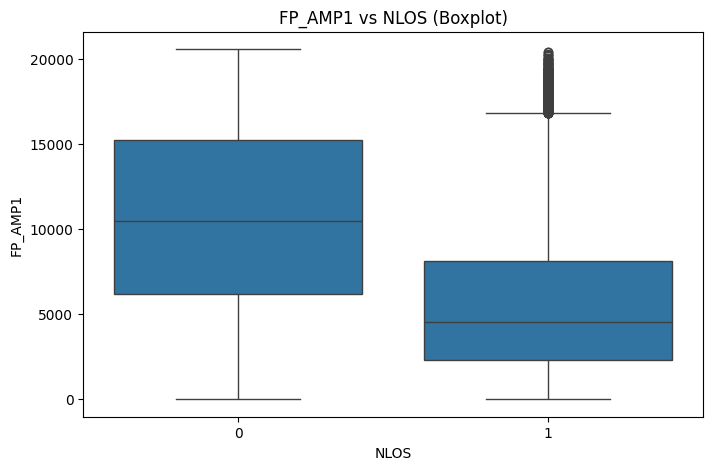

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["NLOS"], y=df["FP_AMP1"])
plt.title("FP_AMP1 vs NLOS (Boxplot)")
plt.show()


In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

X = df["FP_AMP1"].values.reshape(-1, 1)
y = df["NLOS"]

# Linear Model
log_reg = LogisticRegression()
log_reg.fit(X, y)
y_pred_linear = log_reg.predict_proba(X)[:, 1]

# Polynomial Model (Degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
log_reg_poly = LogisticRegression()
log_reg_poly.fit(X_poly, y)
y_pred_poly = log_reg_poly.predict_proba(X_poly)[:, 1]

# Compare AUC Scores
auc_linear = roc_auc_score(y, y_pred_linear)
auc_poly = roc_auc_score(y, y_pred_poly)

print(f"Linear Model AUC: {auc_linear:.4f}")
print(f"Polynomial Model AUC: {auc_poly:.4f}")


Linear Model AUC: 0.7611
Polynomial Model AUC: 0.6914
